In [44]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm.keras import TqdmCallback

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical 

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *

In [45]:
import tensorflow as tf

# Get the build information dictionary
build_info = tf.sysconfig.get_build_info()

# Print the CUDA version it was built for
print("CUDA Version TensorFlow was built with:", build_info.get('cuda_version', 'Not found'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CUDA Version TensorFlow was built with: 12.5.1
Num GPUs Available:  1


In [46]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [47]:
tf.__version__

'2.20.0'

In [48]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [49]:
types, counts = np.unique(master_df.sn_type.values, return_counts = True)
for i in range(len(types)):
    print(types[i], " : ", counts[i])

CaRT  :  52
II  :  1819
IIb  :  542
IIn  :  880
Ia  :  8074
Iap  :  263
Ib  :  262
Ic  :  193
SL  :  1262
TDE  :  96


In [50]:
# Choose the ones with ABC-SN labels only 
index = ~np.isnan(master_df.ABC_type.values)
df = master_df[index]
df = df.reset_index(drop=True)

# creating y array to use for stratification
y = df["ABC_type"].values
index = df.index.values

In [51]:
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = y)

In [52]:
data = dp.extract_dataframe(df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

In [53]:
# one hot encode the y values 
y_ohe = to_categorical(y, num_classes=10)

In [54]:
# Grouped Stratified Sampling
from sklearn.model_selection import StratifiedShuffleSplit

np.random.seed(7)

# Get class distribution
class_counts = df["ABC_type"].value_counts()
print(f"Original class distribution:\n{class_counts}")

# Separate classes into those with >=58 samples and those with <58
classes_with_enough = class_counts[class_counts >= 58].index.tolist()
classes_with_less = class_counts[class_counts < 58].index.tolist()

train_indices = []
test_indices = []

# For classes with enough samples (>=58), take exactly 58
for class_type in classes_with_enough:
    class_indices = df[df["ABC_type"] == class_type].index.tolist()
    train_for_class = np.random.choice(class_indices, size=58, replace=False)
    test_for_class = [idx for idx in class_indices if idx not in train_for_class]
    
    train_indices.extend(train_for_class)
    test_indices.extend(test_for_class)

# For classes with fewer than 58 samples, take ALL to training
for class_type in classes_with_less:
    class_indices = df[df["ABC_type"] == class_type].index.tolist()
    train_indices.extend(class_indices)  # All to training
    # No test samples for this class

# Shuffle the indices
np.random.shuffle(train_indices)
np.random.shuffle(test_indices)

train_index = np.array(train_indices)
test_index = np.array(test_indices)

# Verify
print(f"\nTraining set size: {len(train_index)}")
print(f"Training set class counts:\n{df.loc[train_index, 'ABC_type'].value_counts()}")
print(f"\nTest set size: {len(test_index)}")
print(f"Test set class counts:\n{df.loc[test_index, 'ABC_type'].value_counts()}")


Original class distribution:
ABC_type
0.0    8074
9.0    1819
6.0     542
1.0     263
4.0     262
7.0     193
Name: count, dtype: int64

Training set size: 348
Training set class counts:
ABC_type
4.0    58
9.0    58
0.0    58
7.0    58
6.0    58
1.0    58
Name: count, dtype: int64

Test set size: 10805
Test set class counts:
ABC_type
0.0    8016
9.0    1761
6.0     484
1.0     205
4.0     204
7.0     135
Name: count, dtype: int64


In [55]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

X_train = X[train_index]
X_test = X[test_index]

y_train = y_ohe[train_index]
y_test = y_ohe[test_index]

In [56]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((348, 1, 139), (10805, 1, 139), (348, 10), (10805, 10))

In [57]:
df_test = df.iloc[test_index].copy()

In [58]:
df_test.ABC_type.unique()

array([0., 9., 1., 7., 6., 4.])

## Loading ABC-SN to make predictions


In [59]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)
# abcsn = keras.models.load_model("/lustre/lrspec/users/4301/Milligan_ABC-SN/ABCSN_finetuning100.keras", compile=False)

In [60]:
# need manually compile, using the code from ABC-SN/code/abcsn_training 
loss = keras.losses.CategoricalCrossentropy()
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
# lr0_transfer=1e-5
# optimizer = keras.optimizers.Nadam(learning_rate=lr0_transfer)

## Add Callbacks

In [61]:
# early stopping 
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        min_delta=1e-2, # stated during meeting (note higher than willows)
        patience= 25, # stated in meeting + same as willows
        verbose=2,
        mode="min",
        restore_best_weights=True 
        )

model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint{epoch}.keras"
model_checkpoints = keras.callbacks.ModelCheckpoint(
    model_filepath,
    monitor="val_loss",
    verbose=0,
    mode="min",
    save_best_only=True
    )

epoch_bound = 100
batch_size = 64 # used below
step_bound = len(train_index) * epoch_bound // batch_size

learning_rate_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[step_bound],  # Epoch when the change happens
    values=[1e-5, 2e-6]  # Learning rates: [before boundary, after boundary]
    )


In [62]:
optimizer = keras.optimizers.Nadam(learning_rate=learning_rate_schedule)

abcsn.compile(loss=loss, 
              optimizer=optimizer, 
              metrics=[acc, f1],
             )

In [63]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [102]:
# abcsn.summary()

In [65]:
len(abcsn.trainable_variables)

8

## Retraining

In [66]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((348, 1, 139), (10805, 1, 139), (348, 10), (10805, 10))

In [67]:
history = abcsn.fit(X_train, y_train, 
                    validation_data= (X_test, y_test), 
                    epochs = 500,    # choosen arbitrarily 
                    batch_size = 64, # same as willow used
                    verbose= 0,
                    callbacks=[model_checkpoints, early_stop, TqdmCallback(verbose=0)]
                   )




0epoch [00:00, ?epoch/s]


  6%|▌         | 12/200 [11:02<2:52:56, 55.19s/epoch, ca=0.356, f1=0.214, loss=4.22, val_ca=0.427, val_f1=0.133, val_loss=4.12]
2026-07-08 12:57:24.603864: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



  0%|          | 1/500 [00:07<1:04:08,  7.71s/epoch, ca=0.138, f1=0.0958, loss=8.21, val_ca=0.083, val_f1=0.0358, val_loss=10.7]


  

Epoch 292: early stopping
Restoring model weights from the end of the best epoch: 267.


 58%|█████▊    | 292/500 [10:50<07:43,  2.23s/epoch, ca=0.325, f1=0.195, loss=4.13, val_ca=0.438, val_f1=0.137, val_loss=4.08]


In [99]:
np.argmin(history.history['val_loss'])

np.int64(275)

In [95]:
history.history.keys()

dict_keys(['ca', 'f1', 'loss', 'val_ca', 'val_f1', 'val_loss'])

(4, 5)

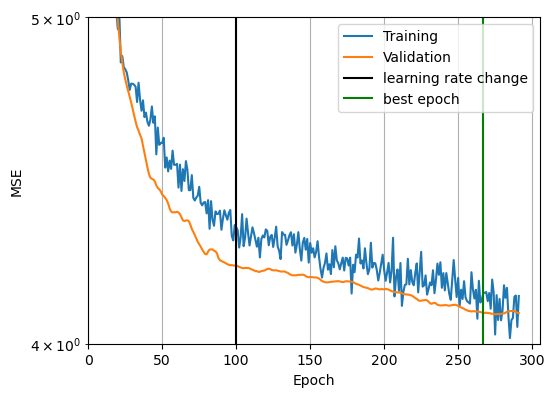

In [101]:
log = history.history
abcsn_training.plot_loss(log, scale=4, cb_es=None, patience_es=None)
plt.axvline(epoch_bound, label= "learning rate change", color = 'k')
plt.axvline(267, label= "best epoch", color = 'g')
plt.legend()
plt.ylim(4,5)

In [70]:
pwd

'/lustre/lrspec/users/4301/Milligan_ABC-SN/notebooks'

In [71]:
abcsn.save("/lustre/lrspec/users/4301/Milligan_ABC-SN/ABCSN_finetuning400_balenced_data.keras")

## Results

In [72]:

# predict type
P = abcsn.predict(X_test, verbose=0)
P_argmax = np.argmax(P, axis=1)

df_test["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
df_test["Pred_Mill_ID"] = P_Mill


2026-07-08 13:08:10.624834: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Checking various types

In [73]:
# Predicted ABC id counts
np.unique(P_argmax, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([4153, 1224,    5,    2, 1360,   21, 1223, 1392,   20, 1405]))

In [74]:
# true ABC ids
Y_ABC_IDs = df_test.ABC_type.values
np.unique(Y_ABC_IDs, return_counts=True)

(array([0., 1., 4., 6., 7., 9.]), array([8016,  205,  204,  484,  135, 1761]))

In [75]:
np.unique(P_Mill, return_counts=True)

(array([0, 1, 2]), array([5384, 4016, 1405]))

# Looking at the results of prediction with ABCSN labels

In [76]:

cr = (classification_report(
    Y_ABC_IDs,
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)
#may be skewed 

              precision    recall  f1-score   support

     Ia-norm       0.93      0.48      0.64      8016
      Ia-91T       0.04      0.21      0.06       205
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.04      0.27      0.07       204
         Ibn       0.00      0.00      0.00         0
         IIb       0.11      0.27      0.15       484
     Ic-norm       0.02      0.23      0.04       135
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.46      0.36      0.41      1761

    accuracy                           0.44     10805
   macro avg       0.16      0.18      0.14     10805
weighted avg       0.77      0.44      0.55     10805



/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [77]:
df_test

,ABC_type,Mill_type,SN_mag,Spectral Phase,host,host_mag,redshift,sn_type,2512.529050300541,2537.7127325827696,...,9279.405394966827,9372.415104528947,9466.357072754703,9561.240643896645,9657.075255867012,9753.870441176497,9851.635827882466,9950.38114054659,Pred_ABC_ID,Pred_Mill_ID
566,0.0,0.0,22.825,0.0,sc,17.823,0.18743,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1972,9.0,2.0,20.770,0.0,sc,22.711,0.18839,II,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4894,9.0,2.0,22.306,0.0,sb,23.247,0.34700,II,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,2
8482,0.0,0.0,20.457,0.0,sc,21.942,0.15406,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,1
8533,0.0,0.0,21.034,0.0,sb,22.976,0.27276,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10916,1.0,0.0,21.774,0.0,sa,23.589,0.20650,Iap,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,2
8000,0.0,0.0,23.042,0.0,sc,21.923,0.37804,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
10944,9.0,2.0,21.908,0.0,sb,23.357,0.09011,II,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,1
7999,0.0,0.0,23.008,0.0,sc,20.906,0.38737,Ia,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


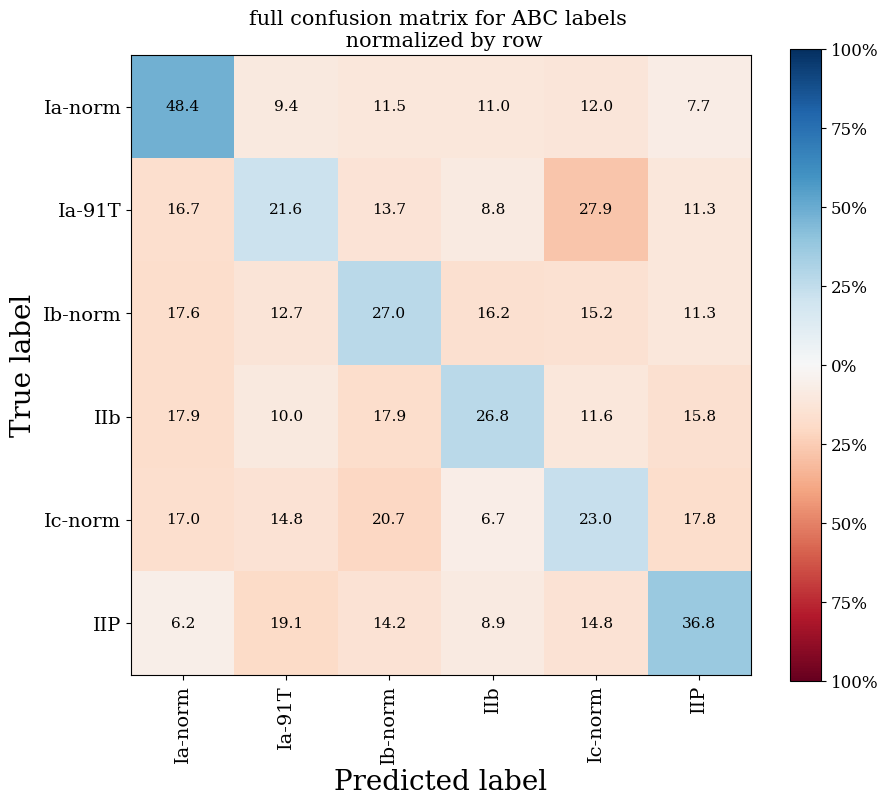

In [78]:
ABC_ID_dict = get_ABC_ID_dict()
labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)]


cm = confusion_matrix(df_test.ABC_type.values, 
                      df_test.Pred_ABC_ID.values,
                     labels = np.unique(Y_ABC_IDs))
plot = plot_cm(cm, labels, 
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

## look at various normalizations

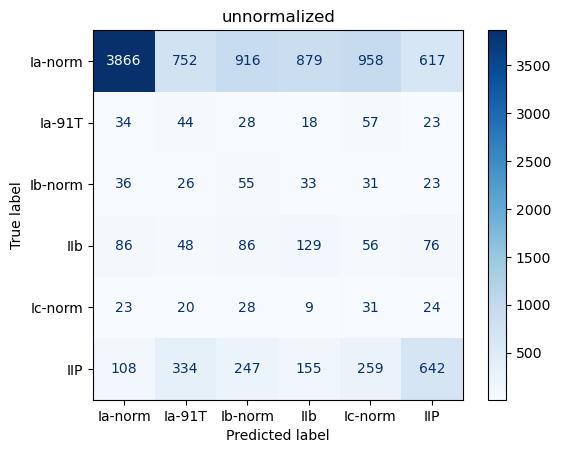

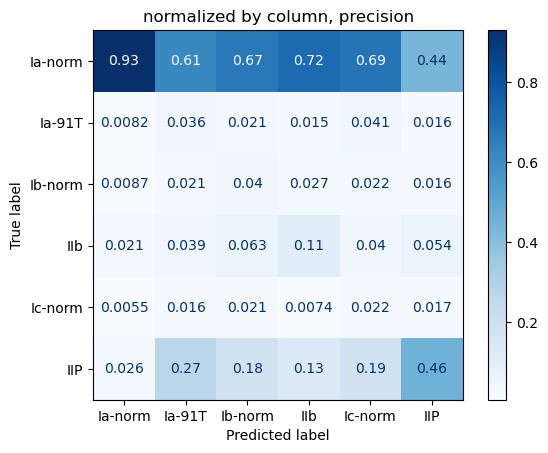

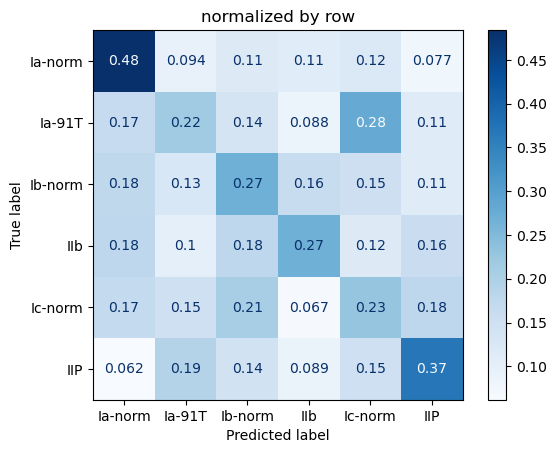

In [79]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(df_test.ABC_type.values, 
                          df_test.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

## Looking at close and bright SN objects

In [80]:

brighter_SN_index = df_test.host_mag > df_test.SN_mag + 1
small_z_index = df_test.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = df_test[bright_close_index].copy()

125


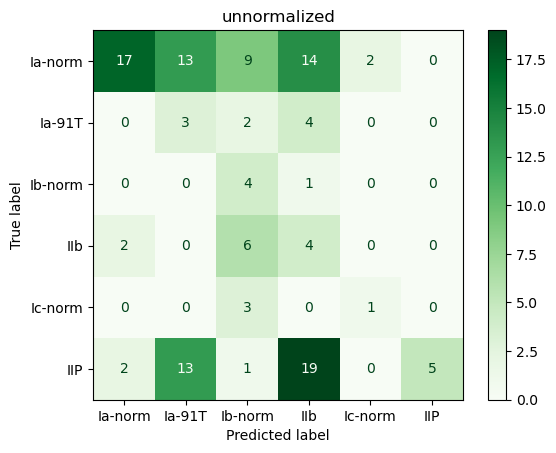

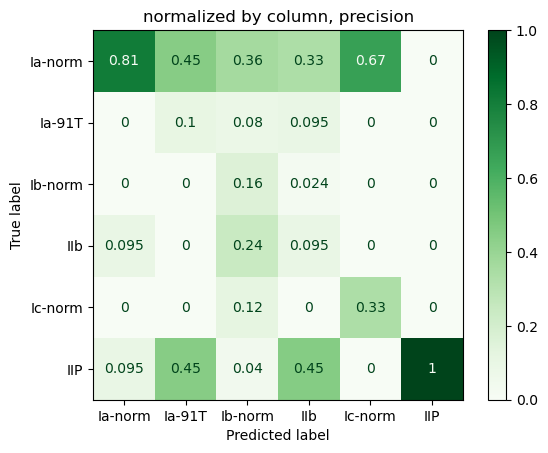

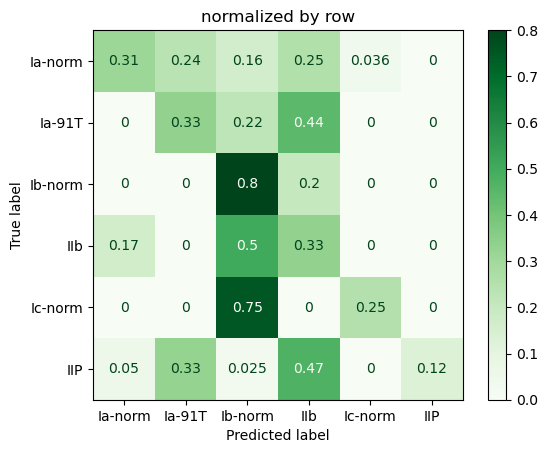

In [81]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values, 
                          bright_close_SN_df.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs),
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

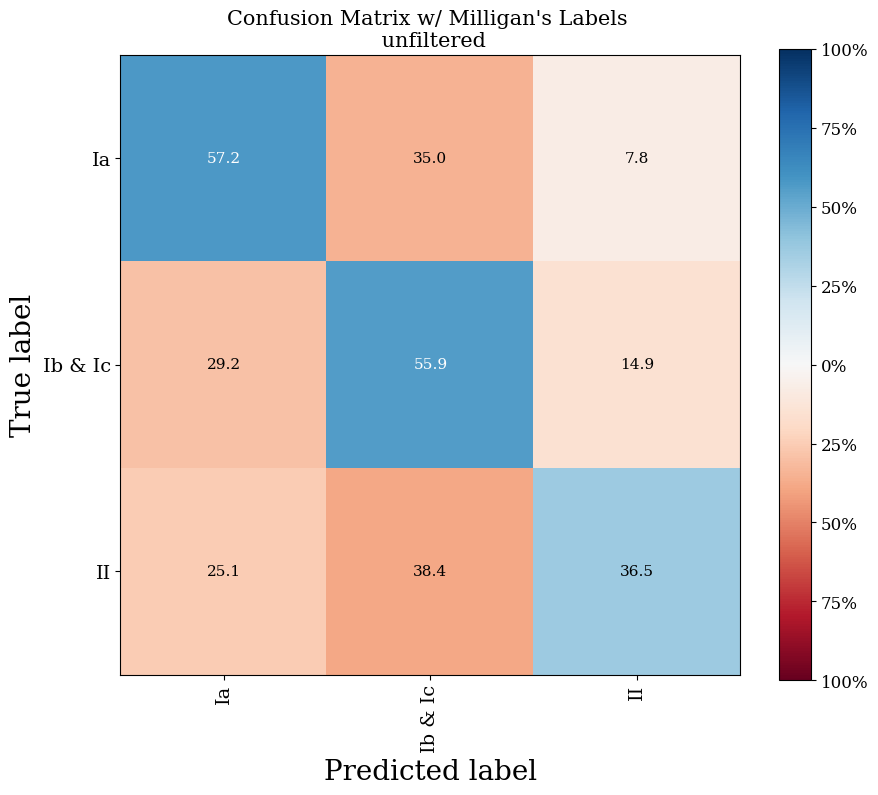

In [82]:

cm_mill = confusion_matrix(df_test.Mill_type, df_test.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

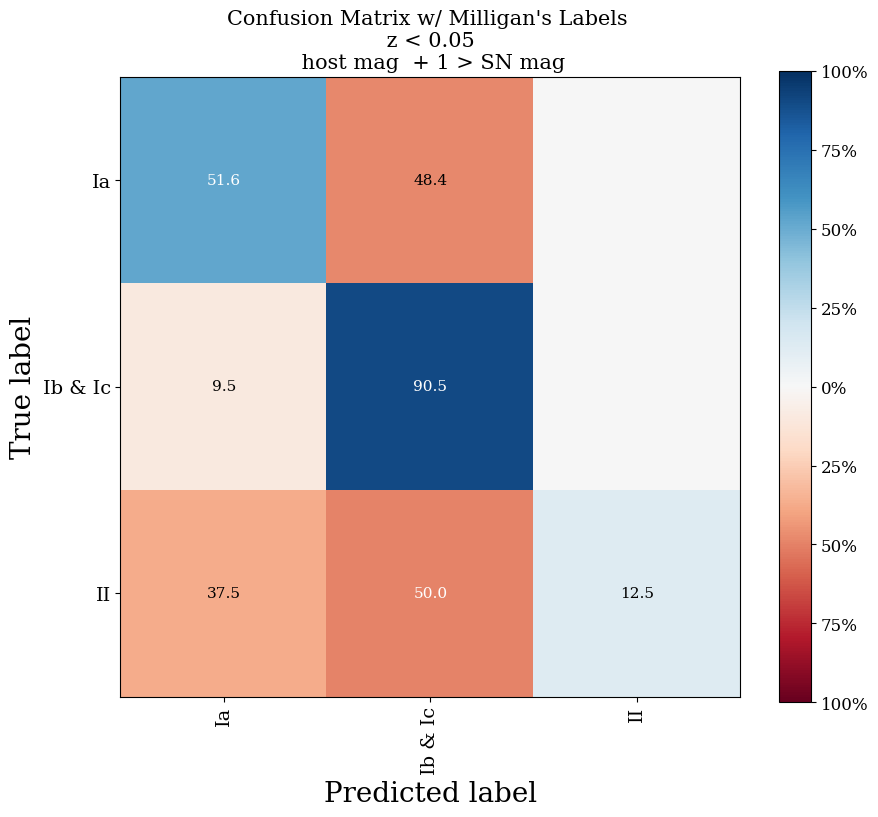

In [83]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra ... not particulary useful

/tmp/ipykernel_64383/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_64383/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_64383/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_64383/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


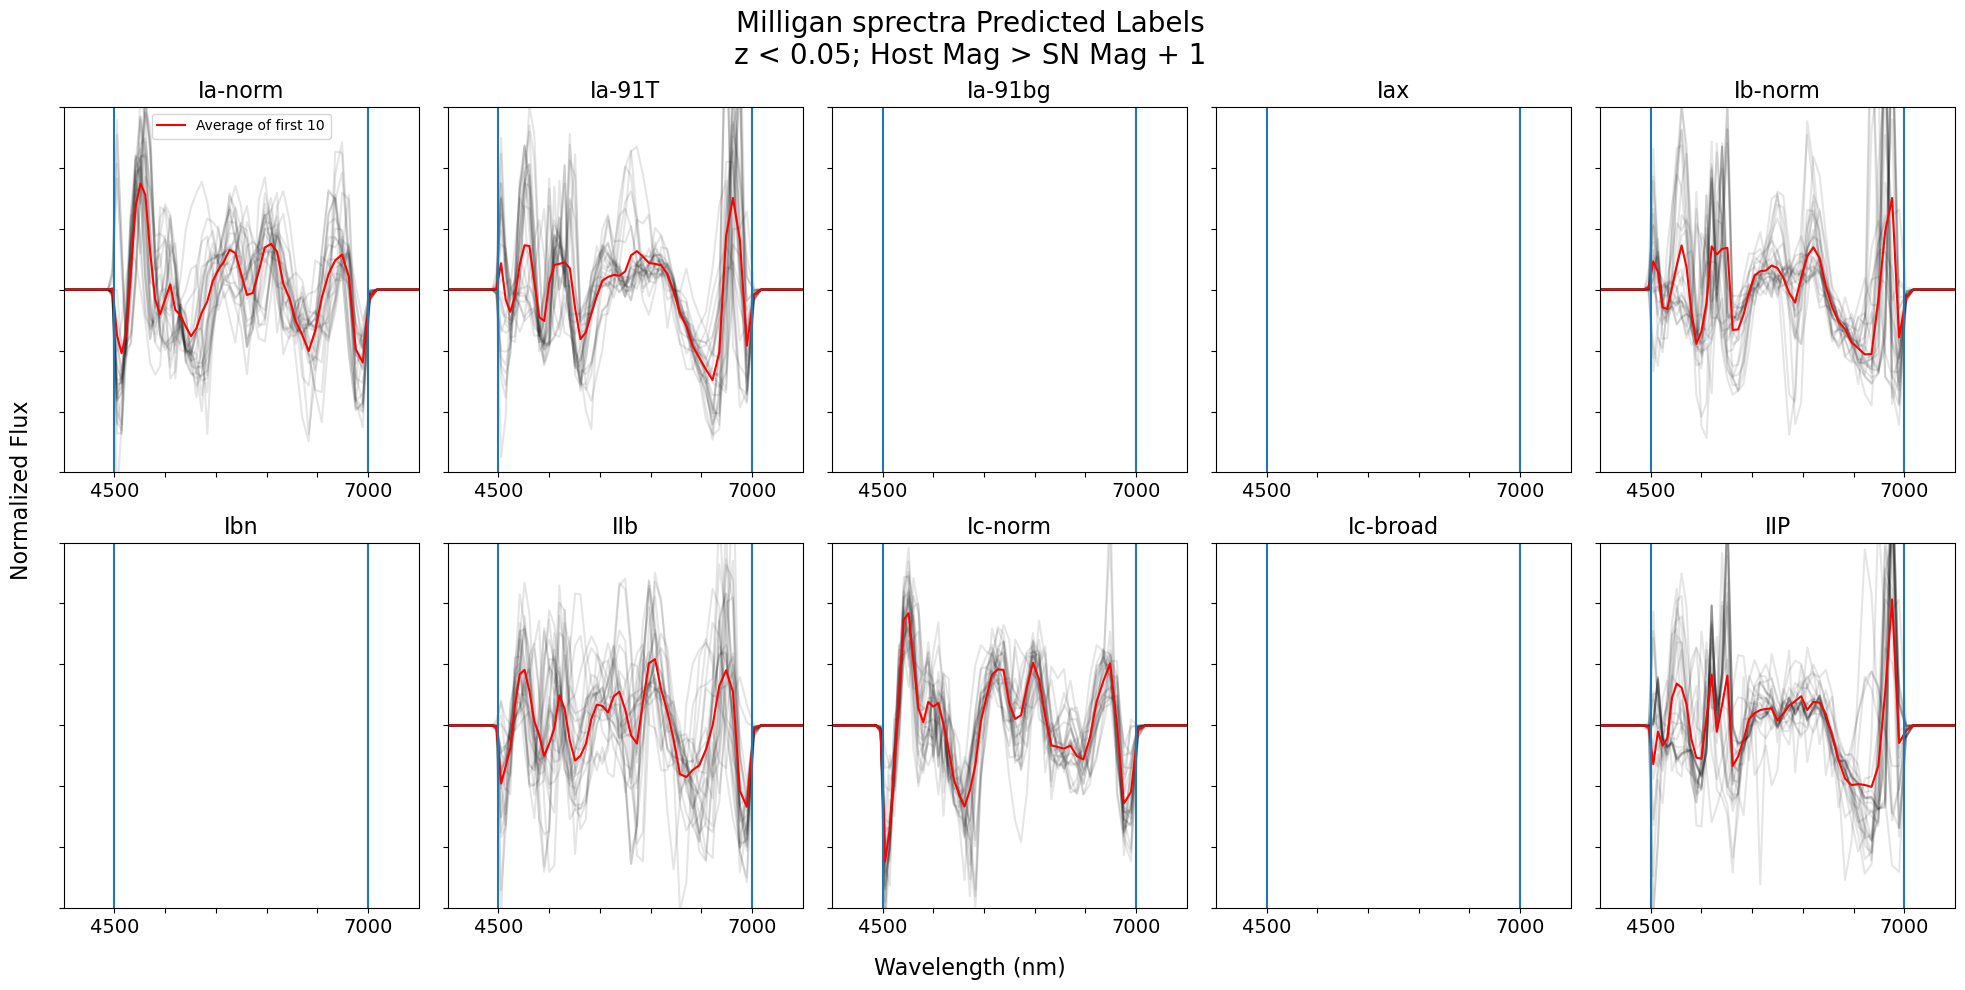

In [84]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df_test.host_mag > df_test.SN_mag +1
small_z_index = df_test.redshift < 0.05
close_bright_df = df_test[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
